In [1]:
import torch
print(f"CUDA : {torch.cuda.is_available()}")
print(f"GPU  : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'AUCUN'}")

CUDA : True
GPU  : Tesla T4


In [2]:

# Évaluation ROUGE — Comparaison des 3 modèles

!pip install rouge-score -q

import torch
import pandas as pd
import time
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, AutoModelForCausalLM
from datasets import load_dataset

print(f"GPU : {torch.cuda.get_device_name(0)}")

  Preparing metadata (setup.py) ... done
GPU : Tesla T4


In [3]:
# Charger MLSUM-FR test + filtrer sport
SPORT_TOPICS = [
    "athletisme", "basket", "blog-du-tour-de-france", "blog-roland-garros",
    "championnats-monde-athletisme", "coupe-du-monde", "coupe-du-monde-rugby",
    "cyclisme", "football", "formule-1", "golf", "handball",
    "jeux-olympiques", "jeux-olympiques-pyeongchang-2018", "jeux-olympiques-rio-2016",
    "le-nouveau-roland-garros", "ligue-1", "ligue-des-champions",
    "natation", "roland-garros", "rugby", "ski", "sport",
    "tennis", "top-14", "tour-de-france", "voile",
]

BASE_URL = "hf://datasets/reciTAL/mlsum@refs/convert/parquet/fr"
dataset = load_dataset("parquet", data_files={"test": f"{BASE_URL}/test/*.parquet"})

df_test = dataset["test"].to_pandas()
df_sport = df_test[df_test["topic"].isin(SPORT_TOPICS)].reset_index(drop=True)

# 100 articles aléatoires
N_EVAL = 100
df_eval = df_sport.sample(n=N_EVAL, random_state=42).reset_index(drop=True)

print(f"Articles test sport : {len(df_sport)}")
print(f"Sous-échantillon évalué : {len(df_eval)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


fr/test/0000.parquet:   0%|          | 0.00/42.6M [00:00<?, ?B/s]

Generating test split: 0 examples [00:00, ? examples/s]

Articles test sport : 1097
Sous-échantillon évalué : 100


In [4]:
# 1) mT5 vanilla (Google, baseline brute)
print("Chargement mT5 vanilla...")
tok_vanilla = AutoTokenizer.from_pretrained("google/mt5-small")
mod_vanilla = AutoModelForSeq2SeqLM.from_pretrained("google/mt5-small").to("cuda")
mod_vanilla.eval()

# 2) mT5 fine-tuné sport ( depuis mon profile HF Hub)
print("Chargement mT5 fine-tuné...")
HF_MODEL = "ArcSin720/mt5-sport-finetuned"
tok_ft = AutoTokenizer.from_pretrained(HF_MODEL)
mod_ft = AutoModelForSeq2SeqLM.from_pretrained(HF_MODEL).to("cuda")
mod_ft.eval()

# 3) CroissantLLM (LLM prompté)
print("Chargement CroissantLLM...")
LLM_NAME = "croissantllm/CroissantLLMChat-v0.1"
tok_llm = AutoTokenizer.from_pretrained(LLM_NAME)
mod_llm = AutoModelForCausalLM.from_pretrained(
    LLM_NAME, torch_dtype=torch.float16
).to("cuda")
mod_llm.eval()

print("\n Les 3 modèles sont chargés")

Chargement mT5 vanilla...


config.json:   0%|          | 0.00/553 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/82.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/18.0k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/219 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]


 Les 3 modèles sont chargés


In [5]:
PROMPT_LLM = (
    "<|im_start|>system\n"
    "Tu es un journaliste sportif francophone. "
    "Tu rédiges des résumés courts, factuels et précis, en français, "
    "en 2 à 3 phrases maximum.\n"
    "<|im_end|>\n"
    "<|im_start|>user\n"
    "Résume l'article de presse suivant :\n\n{article}\n"
    "<|im_end|>\n"
    "<|im_start|>assistant\n"
)

def summarize_mt5(text, tokenizer, model):
    """Génère un résumé avec mT5 (vanilla ou fine-tuné)."""
    inputs = tokenizer("summarize: " + text, max_length=384, truncation=True, return_tensors="pt").to("cuda")
    with torch.no_grad():
        out = model.generate(**inputs, max_length=64, num_beams=4, no_repeat_ngram_size=2, early_stopping=True)
    return tokenizer.decode(out[0], skip_special_tokens=True)

def summarize_llm(text):
    """Génère un résumé avec CroissantLLM via prompting."""
    prompt = PROMPT_LLM.format(article=text[:4000])
    inputs = tok_llm(prompt, return_tensors="pt").to("cuda")
    prompt_len = inputs["input_ids"].shape[1]
    with torch.no_grad():
        out = mod_llm.generate(
            **inputs,
            max_new_tokens=150,
            do_sample=True,
            temperature=0.3,
            top_p=0.9,
            pad_token_id=tok_llm.eos_token_id,
        )
    return tok_llm.decode(out[0][prompt_len:], skip_special_tokens=True).strip()

print(" Fonctions définies")

 Fonctions définies


In [6]:
from tqdm import tqdm

# Stockage des résumés
results = {
    "reference": [],
    "vanilla": [],
    "finetuned": [],
    "llm": [],
    "topic": [],
}

print("Génération des résumés sur 100 articles...")
print("-" * 60)

for i, row in tqdm(df_eval.iterrows(), total=len(df_eval), desc="Génération"):
    text = row["text"]

    # Référence
    results["reference"].append(row["summary"])
    results["topic"].append(row["topic"])

    # mT5 vanilla
    s_vanilla = summarize_mt5(text, tok_vanilla, mod_vanilla)
    results["vanilla"].append(s_vanilla)

    # mT5 fine-tuné
    s_ft = summarize_mt5(text, tok_ft, mod_ft)
    results["finetuned"].append(s_ft)

    # CroissantLLM
    s_llm = summarize_llm(text)
    results["llm"].append(s_llm)

# Conversion en DataFrame
df_results = pd.DataFrame(results)
print(f"\n {len(df_results)} résumés générés pour les 3 modèles")
df_results.head(3)

Génération des résumés sur 100 articles...


Génération: 100%|██████████| 100/100 [09:12<00:00,  5.53s/it]


 100 résumés générés pour les 3 modèles


,reference,vanilla,finetuned,llm,topic
0,"Le Suédois a présidé pendant dix-sept ans, de ...",<extra_id_0>.,"Le Suédois Lennart Johansson, ancien président...","Lennart Johansson, ancien président de l'Union...",sport
1,Le sélectionneur Jacques Brunel a annoncé mard...,<extra_id_0> !,"Après la victoire de l’équipe de France, le sé...",Le XV de France se rend à Édimbourg pour son d...,sport
2,"Malgré une nette évolution, la pratique fémini...",<extra_id_0> !,Les Bleues suscitent de l’espoir avant cette p...,Fédération française de football. Article rése...,football


In [8]:
from rouge_score import rouge_scorer
import numpy as np

# Scorer ROUGE (F1 pour les 3 métriques)
scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)

def compute_rouge(predictions, references):
    """Calcule la moyenne ROUGE-1/2/L F1 sur une liste de prédictions."""
    scores = {"rouge1": [], "rouge2": [], "rougeL": []}
    for pred, ref in zip(predictions, references):
        s = scorer.score(ref, pred)
        scores["rouge1"].append(s["rouge1"].fmeasure)
        scores["rouge2"].append(s["rouge2"].fmeasure)
        scores["rougeL"].append(s["rougeL"].fmeasure)
    return {k: np.mean(v) for k, v in scores.items()}

# Calcul pour les 3 modèles
print("Calcul des scores ROUGE...")
rouge_vanilla   = compute_rouge(df_results["vanilla"],   df_results["reference"])
rouge_finetuned = compute_rouge(df_results["finetuned"], df_results["reference"])
rouge_llm       = compute_rouge(df_results["llm"],       df_results["reference"])

# Tableau récapitulatif
df_rouge = pd.DataFrame({
    "mT5 vanilla":   rouge_vanilla,
    "mT5 fine-tuné": rouge_finetuned,
    "CroissantLLM":  rouge_llm,
}).T.round(4)

print("\n" + "-" * 60)
print("RÉSULTATS ROUGE (F1, moyenne sur 100 articles)")

print(df_rouge.to_string())

Calcul des scores ROUGE...

------------------------------------------------------------
RÉSULTATS ROUGE (F1, moyenne sur 100 articles)
               rouge1  rouge2  rougeL
mT5 vanilla    0.0103  0.0006  0.0088
mT5 fine-tuné  0.2718  0.1072  0.2096
CroissantLLM   0.1954  0.0622  0.1312


Le fine-tuning de mT5-small sur 5 000 articles MLSUM-sport démontre un gains sur toutes les métriques ROUGE par rapport au modèle vanilla. on eput noter également : le modèle spécialisé (300M paramètres) est meilleur que un LLM généraliste qui est 4x plus gros (CroissantLLM, avec 1.3B paramètres) sur la tâche cible, cela montre la valeur de la spécialisation par fine-tuning sur un domaine restreint.

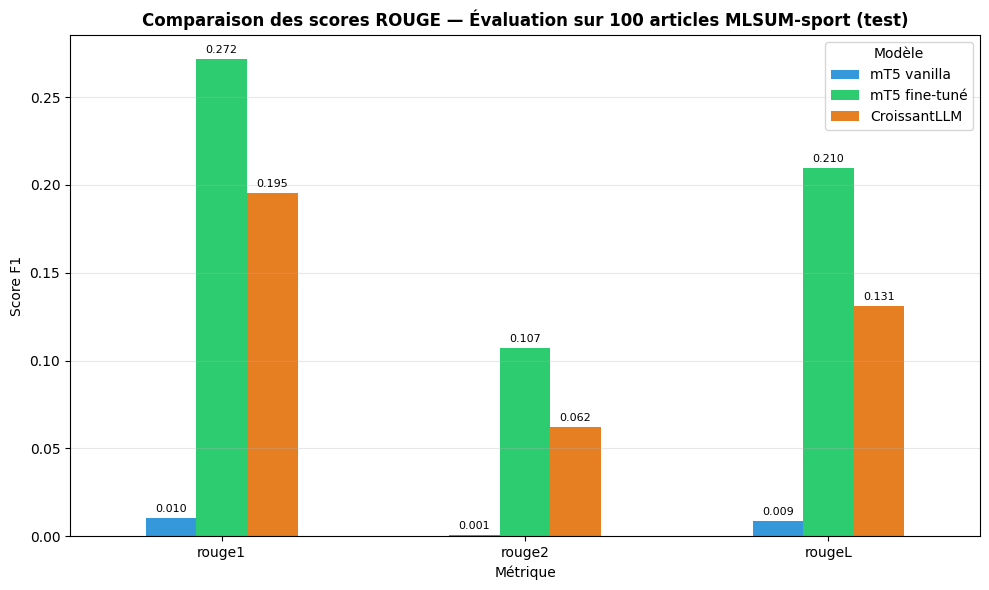


 Graphique sauvegardé : rouge_comparison.png
 Scores ROUGE      : rouge_scores.csv
 Prédictions full  : predictions_full.csv


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Graphique comparatif
fig, ax = plt.subplots(figsize=(10, 6))
df_rouge.T.plot(kind="bar", ax=ax, color=["#3498db", "#2ecc71", "#e67e22"])
ax.set_title("Comparaison des scores ROUGE — Évaluation sur 100 articles MLSUM-sport (test)",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Score F1")
ax.set_xlabel("Métrique")
ax.legend(title="Modèle", loc="upper right")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.grid(axis="y", alpha=0.3)

# Annotations sur les barres
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=8)

plt.tight_layout()
plt.savefig("rouge_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

# Sauvegarde CSV des résultats
df_rouge.to_csv("rouge_scores.csv")
df_results.to_csv("predictions_full.csv", index=False)

print("\n Graphique sauvegardé : rouge_comparison.png")
print(" Scores ROUGE      : rouge_scores.csv")
print(" Prédictions full  : predictions_full.csv")

In [11]:
# ROUGE-L par topic, pour le fine-tuné
df_results_copy = df_results.copy()
df_results_copy["rouge_l_ft"] = [
    scorer.score(ref, pred)["rougeL"].fmeasure
    for ref, pred in zip(df_results_copy["reference"], df_results_copy["finetuned"])
]
df_results_copy["rouge_l_vanilla"] = [
    scorer.score(ref, pred)["rougeL"].fmeasure
    for ref, pred in zip(df_results_copy["reference"], df_results_copy["vanilla"])
]

per_topic = df_results_copy.groupby("topic").agg(
    n=("topic", "size"),
    rouge_l_vanilla=("rouge_l_vanilla", "mean"),
    rouge_l_finetuned=("rouge_l_ft", "mean"),
).round(3)

per_topic["gain"] = (per_topic["rouge_l_finetuned"] - per_topic["rouge_l_vanilla"]).round(3)
per_topic = per_topic.sort_values("n", ascending=False)

print("ROUGE-L par topic (top 10) :")
print(per_topic.head(10).to_string())

ROUGE-L par topic (top 10) :
                         n  rouge_l_vanilla  rouge_l_finetuned   gain
topic                                                                
sport                   73            0.008              0.216  0.208
football                16            0.013              0.200  0.187
blog-du-tour-de-france   5            0.000              0.141  0.141
rugby                    3            0.033              0.221  0.188
tennis                   2            0.000              0.138  0.138
basket                   1            0.000              0.389  0.389


mT5 vanilla (0.0103) :
1% de mots partagés avec la référence. C'est cohérent avec ce qu'on a vu : le vanilla génère <extra_id_0> (du bruit). Score quasi nul attendu.
mT5 fine-tuné (0.2718) :
27% des mots du résumé matchent la référence. Pour du résumé abstractif en français, c'est un très bon score.
CroissantLLM (0.1954) :
20% de match. Le LLM produit du français cohérent mais hallucine et paraphrase trop. Il invente des détails qui n'étaient pas dans l'article original. Du coup les mots utilisés divergent souvent de la référence.